In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm, trange
from IPython.display import display

In [8]:
import yfinance as yf

In [7]:
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20,20)

In [9]:
# Extracting stock data
def get_historical_data(symbol:str, start_date:str) -> pd.DataFrame:
    df = yf.download(symbol, start= start_date, interval="1wk", )
    return df

In [10]:
df = get_historical_data("WMT", "2000-01-01")
display(df.tail())

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2024-06-08,67.190002,67.330002,65.900002,67.019997,67.019997,70526300
2024-06-15,66.919998,68.550003,66.410004,67.910004,67.910004,63948800
2024-06-22,68.050003,69.040001,66.550003,67.709999,67.709999,79267800
2024-06-29,67.889999,70.150002,67.250000,70.040001,70.040001,45976100
2024-07-06,69.900002,70.449997,69.169998,69.239998,69.239998,60404300


In [37]:
# SMA Calculation
def SMA(ohlc: pd.DataFrame, period:int=41, column:str = "Close") -> pd.Series:
    return pd.Series(ohlc[column].rolling(window=period).mean(), name= f"{period}perod SMA")

In [39]:
# DEMA Calculation
def DEMA(ohlc :pd.DataFrame, period:int = 20, column:str = "Close") -> pd.Series:
    ema = ohlc[column].ewm(span = period, adjust = False).mean()
    DEMA = 2*ema - ema.ewm(span = period, adjust = False).mean()
    return DEMA

In [43]:
# Get Best window

def get_best_window(s:pd.Series) ->tuple[int,int]:
    best_roi = - np.inf
    best_window = None
    df = s.to_frame()
    for short_window in range(5,51):
        for long_window in range(5,51):
            df["DEMA_short"] = DEMA(df, period=short_window)
            df["DEMA_long"] = DEMA(df, period=long_window)

            df["Position"] = 0
            position_number = df.columns.tolist().index("Position")
            df.iloc[short_window:, position_number] = np.where(df["DEMA_short"][short_window:] > 
                                                               df["DEMA_long"][short_window:],1,0)
            
            df["Daily_Return"] = df["Close"].pct_change()
            df["Strategy_Return"]= df["Position"].shift(1)*df["Daily_Return"]
            cum_return = df["Strategy_Return"][long_window:].add(1).cumprod().sub(1)
            roi = cum_return.iloc[-1]


            if roi > best_roi:
                best_roi = roi
                best_window = (short_window, long_window)
    return best_window

In [44]:
short_window, long_window = get_best_window(df["Close"])
df["DEMA_short"] = DEMA(df, period=short_window)
df["DEMA_long"] = DEMA(df, period = long_window)
df

,Open,High,Low,Close,Adj Close,Volume,DEMA_short,DEMA_long
Date,,,,,,,,
2000-01-01,22.791668,23.000000,20.729168,22.833332,14.783646,109965300,22.833332,22.833332
2000-01-08,22.416668,22.583332,21.333332,21.500000,13.920369,81227400,22.649659,22.520832
2000-01-15,21.062500,22.145832,20.687500,20.812500,13.475248,71858100,22.390715,22.104491
2000-01-22,21.145832,21.145832,17.833332,18.375000,11.897060,120284400,21.823612,21.194254
2000-01-29,18.187500,20.041668,18.041668,18.770832,12.153343,107745000,21.371563,20.546076
...,...,...,...,...,...,...,...,...
2024-06-08,67.190002,67.330002,65.900002,67.019997,67.019997,70526300,64.101571,65.642454
2024-06-15,66.919998,68.550003,66.410004,67.910004,67.910004,63948800,64.903354,66.542551
2024-06-22,68.050003,69.040001,66.550003,67.709999,67.709999,79267800,65.582476,67.206177


In [45]:
# Compute result


df["Position"] = 0
position_number = df.columns.tolist().index("Position")
df.iloc[short_window:, position_number] = np.where(df["DEMA_short"][short_window:] > 
                                                   df["DEMA_long"][short_window:],1,0)

buy_price = df.loc[df["Position"] ==1, "Close"]
sell_price =  df.loc[df["Position"]==0, "Close"]

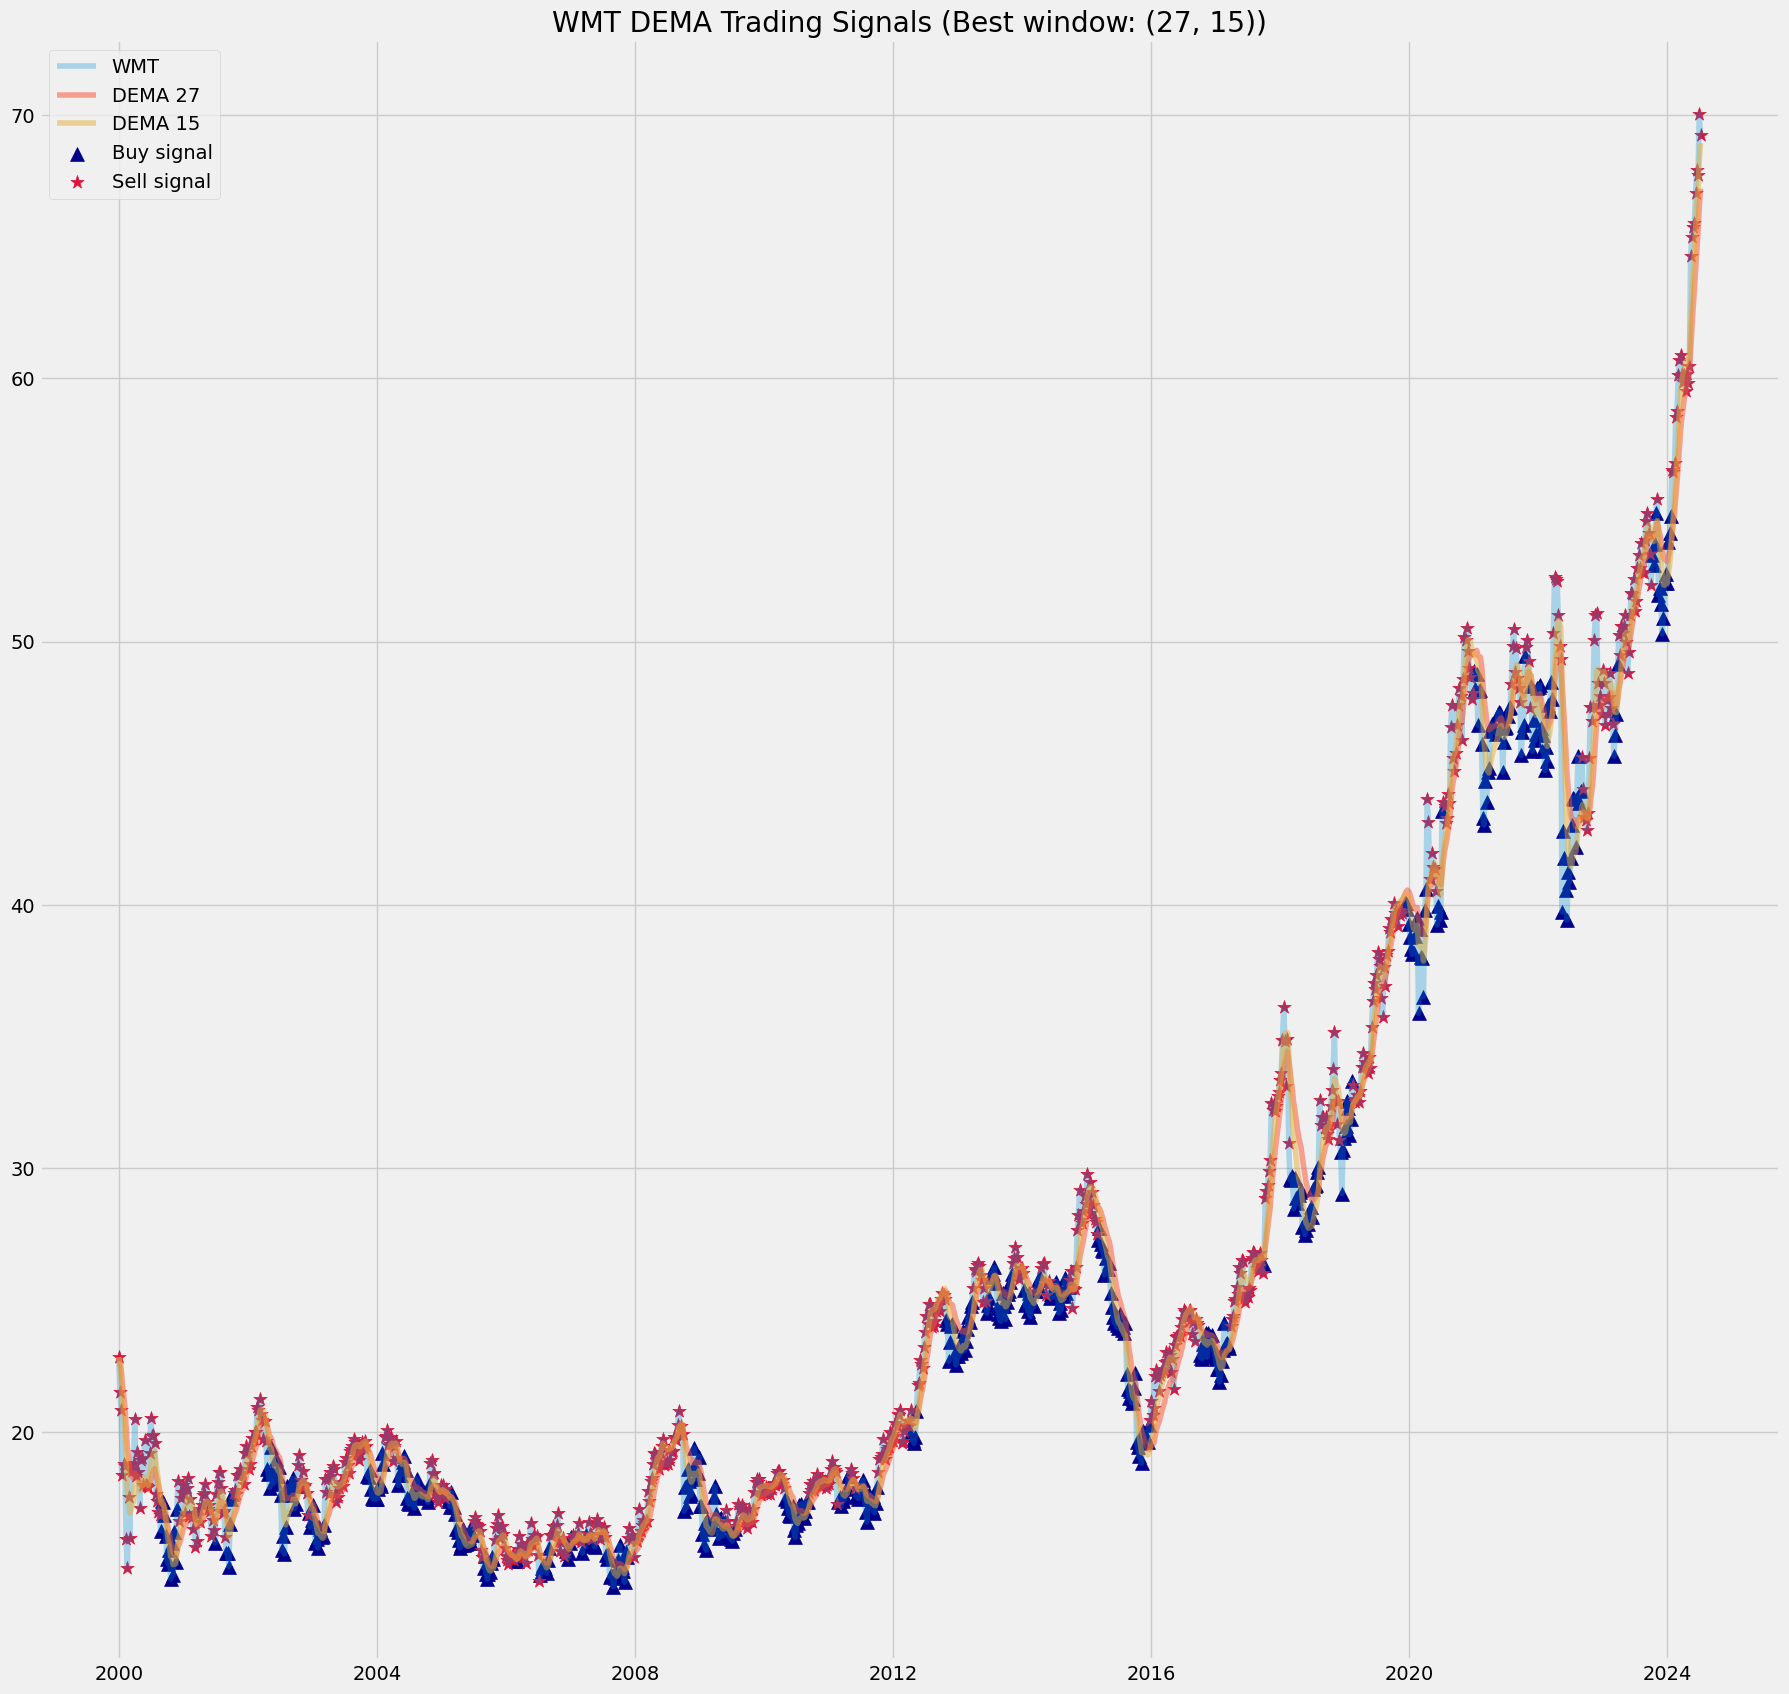

In [48]:
# Plot signal

plt.plot(df["Close"], alpha = 0.3, label = "WMT")
plt.plot(df["DEMA_short"], alpha = 0.5, label = f"DEMA {short_window}")
plt.plot(df["DEMA_long"], alpha = 0.5, label = f"DEMA {long_window}")

plt.scatter(buy_price.index, buy_price, marker= "^", s = 100, color = "darkblue", label = "Buy signal")
plt.scatter(sell_price.index, sell_price, marker= "*", s = 100, color = "crimson", label = "Sell signal")
plt.legend(loc = "upper left")

plt.title((f"WMT DEMA Trading Signals (Best window: {short_window, long_window})"))
plt.show()

In [49]:
# Compute cumulative return

df["Daily_Return"] = df["Close"].pct_change()
df["Strategy_Return"] = df["Position"].shift(1)*df["Daily_Return"]
rets_cum = df["Daily_Return"].add(1).cumprod().sub(1)
strats_cum = df["Strategy_Return"].add(1).cumprod().sub(1)

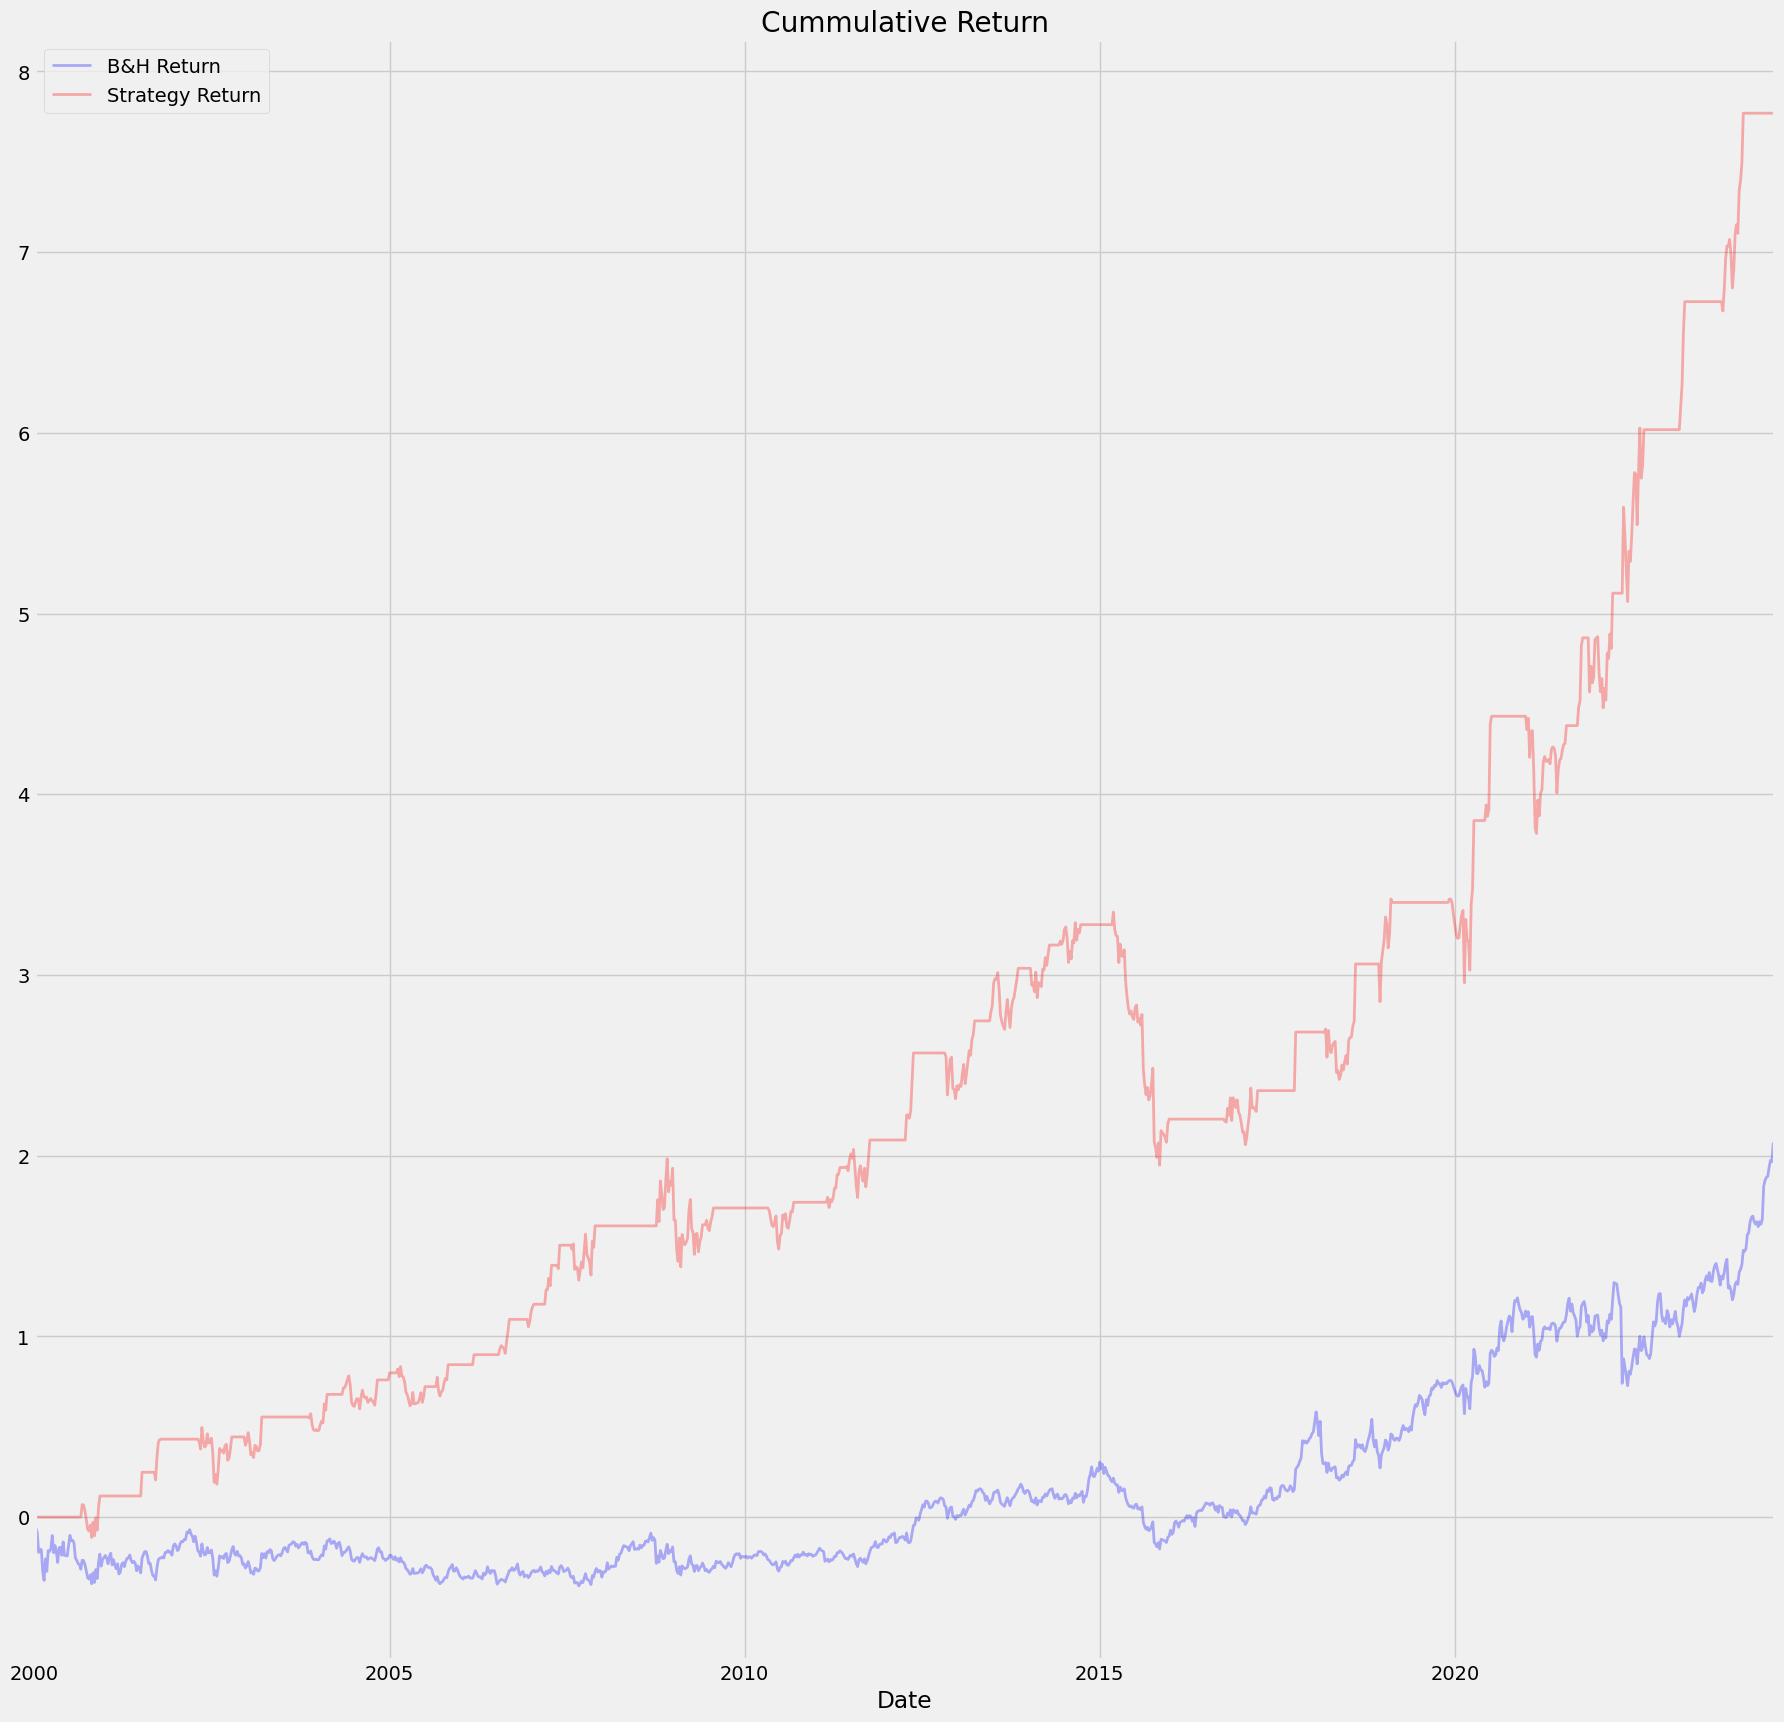

In [50]:
#Plot cumulative results

plt.title("Cummulative Return")
rets_cum.plot(color= 'blue', label = "B&H Return", alpha = 0.3, linewidth = 2)
strats_cum.plot(color = 'r', label = "Strategy Return", alpha = 0.3, linewidth = 2)
plt.legend(loc = "upper left")
plt.show()